In [5]:
#goal is to collect the methylation scores for patients at baseline, run PCA, then run clustering

# libraries

In [6]:
import patientClassFunctions as ptfn
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import os
# import seaborn as sns
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
#for the clustering
from IPython.display import SVG
from sknetwork.clustering import Louvain, get_modularity
from sknetwork.linalg import normalize
from sknetwork.utils import get_membership
from sknetwork.visualization import visualize_graph, visualize_bigraph

# directory management

In [8]:
computer_path_header = "C:\\Users\\maega"
# computer_path_header = "C:\\Users\\mcremer"
folder_path2= "UFL Dropbox\\Maegan Cremer\\BTO-data"
folder_path_processed = "012_Processed_Data"
path_ptdata = os.path.join(computer_path_header, folder_path2, folder_path_processed, "patient_files")
os.chdir(path_ptdata)

# file importing and patient class

In [9]:
#importing patient data as dictionaries of dataframes

#build a dictionary of patients and their values 
ptFiles = ptfn.GetListofPTfiles(path_ptdata, '.xlsx', 'BTO')

ptDict = {}

#loop through the listOfPatients 
for file in ptFiles: 
    pt = ptfn.patient(path_ptdata, file, 7)
    ptDict[pt.ptID] = pt

BTO-002 no patient identifying information
BTO-051 no patient identifying information
BTO-081 no patient identifying information


# collecting baseline methylation scores and tumor types

In [10]:
# methylationDict = {}
# for pt in ptDict.keys():
#     ptMethylSheet = ptDict[pt].methylationSignatures
#     if ptMethylSheet is not False: 
#        methylationDict[pt] = ptMethylSheet.iloc[0]

In [11]:
# test_primary = {}
methylationDict = {}

tumortypeDict = {}
primarytumorEnrollementDict = {}

metEnrollmentDict = {}
metEnrollmentPresence = {}

for ptID in ptDict.keys():
    ptdata = ptDict[ptID]
    if ptdata.methylationSignatures is not False and ptdata.ptDemographics is not False:
        methylationDict[ptID] = ptdata.methylationSignatures.iloc[0]
        tumortypeDict[ptID] = ptdata.primarytumor #numeric code for type of primary tumor
        primarytumorEnrollementDict[ptID]= ptdata.primarytumorEnrollment #binary if primary tumor is present at enrollment
        metEnrollmentDict[ptID] = ptdata.metEnrollmentList #numeric list of locations of mets at enrollment 
        metEnrollmentPresence[ptID] = ptdata.metsAtEnrollment #length of met sites

print(len(tumortypeDict.keys()))
print(len(methylationDict.keys()))

102
102


In [12]:
metEnrollmentDict

{'BTO-003': [1],
 'BTO-004': [5],
 'BTO-005': [2],
 'BTO-006': [5],
 'BTO-007': [2],
 'BTO-008': [1],
 'BTO-009': [2],
 'BTO-010': [1, 2],
 'BTO-011': [3],
 'BTO-012': [1, 2],
 'BTO-013': [5],
 'BTO-016': [4, 5],
 'BTO-018': [2],
 'BTO-019': [1, 2],
 'BTO-022': [1],
 'BTO-025': [],
 'BTO-026': [1],
 'BTO-027': [5],
 'BTO-030': [1, 2, 5],
 'BTO-031': [],
 'BTO-032': [1, 5],
 'BTO-033': [4],
 'BTO-034': [],
 'BTO-035': [5],
 'BTO-038': [1],
 'BTO-039': [2, 4],
 'BTO-040': [2, 4, 5],
 'BTO-041': [2],
 'BTO-042': [1],
 'BTO-043': [3, 5],
 'BTO-044': [1, 4],
 'BTO-045': [1, 2],
 'BTO-046': [6],
 'BTO-047': [3],
 'BTO-048': [5],
 'BTO-049': [1, 2, 3, 4],
 'BTO-052': [6],
 'BTO-053': [2, 3, 6],
 'BTO-055': [2, 3],
 'BTO-056': [2, 5],
 'BTO-058': [4],
 'BTO-059': [1, 2, 6],
 'BTO-060': [],
 'BTO-061': [2],
 'BTO-062': [],
 'BTO-066': [1],
 'BTO-067': [],
 'BTO-068': [],
 'BTO-070': [1, 2, 5],
 'BTO-071': [2, 4, 5],
 'BTO-072': [1, 3, 5],
 'BTO-073': [1, 2, 5],
 'BTO-074': [6],
 'BTO-075': [2, 

In [13]:
#concatinate the dictionary into a dataframe
baseline_methyl= pd.DataFrame.from_dict(methylationDict).T
baseline_methyl

,Unnamed: 0,10_q24.2_1,8_q21.3_1,1_p13.3_1,10_q22.1_1,11_q25_1,12_q24.33_1,15_q21.1_1,15_q26.3_1,16_p13.3_2,...,8_q24.22_12,21_q22.11_7,7_q21.3_29,10_q26.13_9,12_q24.33_12,6_p12.1_21,17_p11.2_20,2_q14.2_22,2_q31.1_39,date
BTO-003,NS1035CR0007,-0.003047,-0.002742,-0.003496,0,0,0.0,0,0.0,-0.002401,...,-0.000773,-0.0,-0.000027,-0.0,-0.058974,-0.0,-0.000914,-0.087552,-0.003496,2023-06-15
BTO-004,NS1035CR0050,0.565549,16.139794,5.103303,0,0,8.386749,0,-0.000799,1.25611,...,17.581399,0.20849,10.385714,13.096638,17.19679,36.643117,1.826021,41.978462,23.174834,2023-07-10
BTO-005,NS1035CR0006,0,0,0,0,0,0,0,0,0,...,0,-0.004151,4.595732,-0.003911,-0.000661,-0.000148,-0.004114,-0.000033,-0.003357,2023-06-15
BTO-006,NS1035CR0005,-0.008418,0,2.638062,33.482938,0,-0.007767,0,-0.005289,-0.000677,...,11.821301,-0.000001,-0.000005,-0.061959,-0.0,-0.0,10.166206,-0.0,15.719067,2023-06-15
BTO-007,NS1035CR0003,0.118923,7.261357,0,0,0,6.285144,0,0,-0.003701,...,3.596806,0.003356,10.289315,12.248215,21.522951,5.09483,0.103686,0.177697,0.674727,2023-06-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BTO-129,NS1035CR0599,1.318768,1.013769,0.902653,0,0,2.112797,0,0.0,-0.004524,...,9.50248,3.949728,1.4354,-0.002392,14.788832,13.351018,-0.000001,0.540951,0.400348,2025-01-06
BTO-130,NS1035CR0591,7.686069,61.836314,80.761902,0,4.443201,111.922232,0,0.0,-0.003994,...,302.812946,63.606126,35.899534,-0.0,377.497958,401.23069,75.111154,286.594252,-0.003838,2025-01-15
BTO-131,NS1035CR0629,-0.002579,0.0,0,0,0,1.017081,0,-0.005342,-0.00479,...,4.266083,0.635374,1.310697,1.579426,0.811097,-0.20181,0.172293,-0.012694,1.446281,2025-02-03
BTO-132,NS1035CR0626,0.0,0,50.140881,0,0,86.935666,0,0.0,-0.003223,...,315.461813,63.697305,72.380116,0.237611,215.533274,202.799395,0.836753,70.927252,-0.004086,2025-01-29


In [14]:
metEnrollmentPresence

{'BTO-003': 1,
 'BTO-004': 1,
 'BTO-005': 1,
 'BTO-006': 1,
 'BTO-007': 1,
 'BTO-008': 1,
 'BTO-009': 1,
 'BTO-010': 2,
 'BTO-011': 1,
 'BTO-012': 2,
 'BTO-013': 1,
 'BTO-016': 2,
 'BTO-018': 1,
 'BTO-019': 2,
 'BTO-022': 1,
 'BTO-025': 0,
 'BTO-026': 1,
 'BTO-027': 1,
 'BTO-030': 3,
 'BTO-031': 0,
 'BTO-032': 2,
 'BTO-033': 1,
 'BTO-034': 0,
 'BTO-035': 1,
 'BTO-038': 1,
 'BTO-039': 2,
 'BTO-040': 3,
 'BTO-041': 1,
 'BTO-042': 1,
 'BTO-043': 2,
 'BTO-044': 2,
 'BTO-045': 2,
 'BTO-046': 1,
 'BTO-047': 1,
 'BTO-048': 1,
 'BTO-049': 4,
 'BTO-052': 1,
 'BTO-053': 3,
 'BTO-055': 2,
 'BTO-056': 2,
 'BTO-058': 1,
 'BTO-059': 3,
 'BTO-060': 0,
 'BTO-061': 1,
 'BTO-062': 0,
 'BTO-066': 1,
 'BTO-067': 0,
 'BTO-068': 0,
 'BTO-070': 3,
 'BTO-071': 3,
 'BTO-072': 3,
 'BTO-073': 3,
 'BTO-074': 1,
 'BTO-075': 2,
 'BTO-076': 2,
 'BTO-077': 2,
 'BTO-078': 1,
 'BTO-079': 3,
 'BTO-080': 1,
 'BTO-082': 1,
 'BTO-083': 2,
 'BTO-084': 1,
 'BTO-086': 2,
 'BTO-087': 0,
 'BTO-088': 2,
 'BTO-089': 1,
 'BTO-090'

In [15]:
pd.DataFrame.from_dict(metEnrollmentPresence, orient='index')

,0
BTO-003,1
BTO-004,1
BTO-005,1
BTO-006,1
BTO-007,1
...,...
BTO-129,2
BTO-130,2
BTO-131,4
BTO-132,4


In [16]:
pd.DataFrame.from_dict(metEnrollmentDict, orient = 'index')

,0,1,2,3,4
BTO-003,1.0,NaN,NaN,NaN,NaN
BTO-004,5.0,NaN,NaN,NaN,NaN
BTO-005,2.0,NaN,NaN,NaN,NaN
BTO-006,5.0,NaN,NaN,NaN,NaN
BTO-007,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
BTO-129,1.0,5.0,NaN,NaN,NaN
BTO-130,1.0,2.0,NaN,NaN,NaN
BTO-131,1.0,2.0,4.0,5.0,NaN
BTO-132,1.0,2.0,5.0,6.0,NaN


In [17]:
baseline_methyl_clean = baseline_methyl.drop(["Unnamed: 0", "date"], axis = 1)
baseline_methyl_clean

,10_q24.2_1,8_q21.3_1,1_p13.3_1,10_q22.1_1,11_q25_1,12_q24.33_1,15_q21.1_1,15_q26.3_1,16_p13.3_2,16_p12.2_1,...,7_q36.3_22,8_q24.22_12,21_q22.11_7,7_q21.3_29,10_q26.13_9,12_q24.33_12,6_p12.1_21,17_p11.2_20,2_q14.2_22,2_q31.1_39
BTO-003,-0.003047,-0.002742,-0.003496,0,0,0.0,0,0.0,-0.002401,0,...,-0.000128,-0.000773,-0.0,-0.000027,-0.0,-0.058974,-0.0,-0.000914,-0.087552,-0.003496
BTO-004,0.565549,16.139794,5.103303,0,0,8.386749,0,-0.000799,1.25611,11.702328,...,21.964323,17.581399,0.20849,10.385714,13.096638,17.19679,36.643117,1.826021,41.978462,23.174834
BTO-005,0,0,0,0,0,0,0,0,0,0,...,-0.00308,0,-0.004151,4.595732,-0.003911,-0.000661,-0.000148,-0.004114,-0.000033,-0.003357
BTO-006,-0.008418,0,2.638062,33.482938,0,-0.007767,0,-0.005289,-0.000677,0,...,11.314878,11.821301,-0.000001,-0.000005,-0.061959,-0.0,-0.0,10.166206,-0.0,15.719067
BTO-007,0.118923,7.261357,0,0,0,6.285144,0,0,-0.003701,0.371284,...,6.051951,3.596806,0.003356,10.289315,12.248215,21.522951,5.09483,0.103686,0.177697,0.674727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BTO-129,1.318768,1.013769,0.902653,0,0,2.112797,0,0.0,-0.004524,7.80669,...,20.936702,9.50248,3.949728,1.4354,-0.002392,14.788832,13.351018,-0.000001,0.540951,0.400348
BTO-130,7.686069,61.836314,80.761902,0,4.443201,111.922232,0,0.0,-0.003994,2.290844,...,355.06544,302.812946,63.606126,35.899534,-0.0,377.497958,401.23069,75.111154,286.594252,-0.003838
BTO-131,-0.002579,0.0,0,0,0,1.017081,0,-0.005342,-0.00479,0.0,...,1.317695,4.266083,0.635374,1.310697,1.579426,0.811097,-0.20181,0.172293,-0.012694,1.446281
BTO-132,0.0,0,50.140881,0,0,86.935666,0,0.0,-0.003223,0,...,0.6725,315.461813,63.697305,72.380116,0.237611,215.533274,202.799395,0.836753,70.927252,-0.004086


In [18]:
primaryTumorType = pd.DataFrame.from_dict(tumortypeDict, orient = "index")
primaryTumorType

,0
BTO-003,1
BTO-004,1
BTO-005,2
BTO-006,1
BTO-007,2
...,...
BTO-129,5
BTO-130,5
BTO-131,4
BTO-132,5


# test train split

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
# X_train , X_test , y_train, y_test = train_test_split(baseline_methyl_clean, primaryTumorType, test_size = 0.20, random_state = 0)
# #standard scalar 
# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)

In [21]:
#if no test-train split is being conducted 
sc = StandardScaler()
X_train = sc.fit_transform(baseline_methyl_clean)


# PCA 

In [22]:
from sklearn.decomposition import PCA

In [23]:
# pca = PCA(n_components=2)
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)
# explained_variance = pca.explained_variance_ratio_

In [ ]:
pca = PCA()
y_train = primaryTumorType
X_train_pca = pca.fit_transform(X_train)
explained_variance = pca.explained_variance_ratio_

In [25]:
explained_variance

array([4.47743034e-01, 9.18969296e-02, 8.05108996e-02, 5.00017437e-02,
       4.13693729e-02, 4.06811409e-02, 3.03016928e-02, 2.84687514e-02,
       2.36352224e-02, 2.21575502e-02, 1.99638064e-02, 1.64334964e-02,
       1.46352915e-02, 1.25963073e-02, 9.61356812e-03, 7.55667343e-03,
       6.40367890e-03, 5.83162720e-03, 4.43349459e-03, 3.93105045e-03,
       3.66476902e-03, 3.39842951e-03, 3.02024178e-03, 2.84899028e-03,
       2.72042901e-03, 2.38773424e-03, 2.35455344e-03, 2.27454172e-03,
       1.87083783e-03, 1.68959928e-03, 1.49800864e-03, 1.39836883e-03,
       1.20722788e-03, 1.09964560e-03, 1.01375394e-03, 9.75759252e-04,
       8.39978995e-04, 7.34832574e-04, 6.96106909e-04, 6.56545065e-04,
       5.64274309e-04, 5.34405773e-04, 4.94544711e-04, 4.70092623e-04,
       4.40908453e-04, 3.99540475e-04, 3.23215846e-04, 3.06440949e-04,
       2.70059044e-04, 1.98808469e-04, 1.66956789e-04, 1.46797590e-04,
       1.33274469e-04, 1.16176035e-04, 9.22579511e-05, 9.06023494e-05,
      

<BarContainer object of 102 artists>

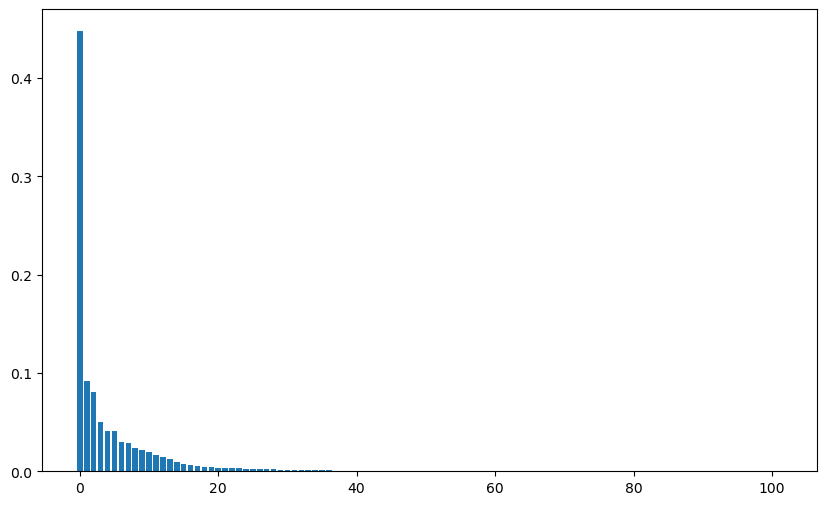

In [40]:
#elbow plot
fig, ax = plt.subplots(figsize = (10,6))

ax.bar(range(0,len(explained_variance),1),explained_variance)

In [28]:
X_train_pca

array([[-1.43882375e+01,  4.69459096e-01,  1.79188873e-01, ...,
         1.26230414e-06,  5.77368913e-05, -1.37913725e-14],
       [-4.28656281e+00, -8.51428088e-01,  2.58551671e+00, ...,
         1.81399330e-05, -1.71400217e-05, -1.37913725e-14],
       [-1.33621939e+01,  1.25222529e-01,  1.59094603e+00, ...,
         2.37233644e-05,  4.51652957e-05, -1.37913725e-14],
       ...,
       [-1.48030322e+01,  9.38612184e-01, -3.58788081e-02, ...,
         1.04180348e-04, -1.24874442e-03, -1.37913725e-14],
       [ 3.56974230e+01, -6.48674428e+00, -2.69362453e+01, ...,
         8.08852467e-06, -2.97251313e-05, -1.37913725e-14],
       [-1.34965213e+01,  1.22542731e+00,  1.91106113e-01, ...,
         2.10731871e-04,  2.18219798e-05, -1.37913725e-14]],
      shape=(102, 102))

<BarContainer object of 8 artists>

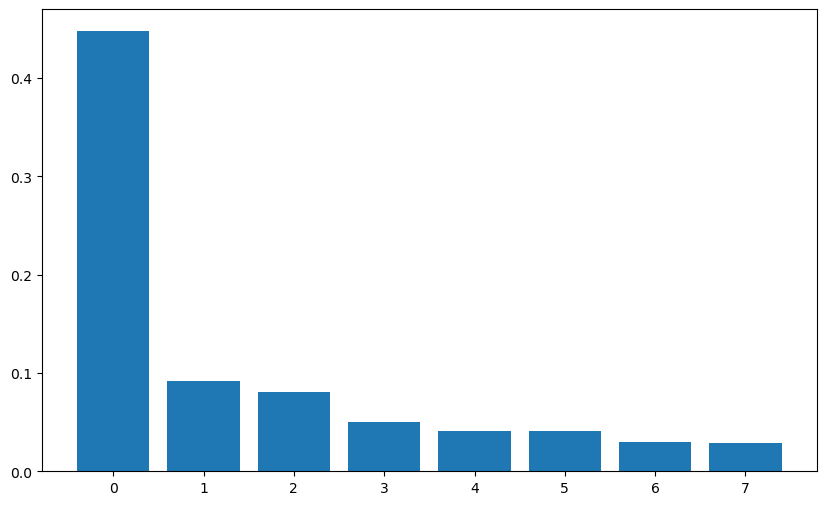

In [42]:
pca = PCA(n_components=8)
y_train = primaryTumorType
X_train_pca = pca.fit_transform(X_train)
explained_variance = pca.explained_variance_ratio_

#elbow plot
fig, ax = plt.subplots(figsize = (10,6))

ax.bar(range(0,len(explained_variance),1),explained_variance)

# Louvain clustering

https://sib-swiss.github.io/single-cell-python-training/ipynb/day2-2_integration.html

In [60]:
from sklearn.neighbors import NearestNeighbors

In [71]:
#start with KNN 
nbrs = NearestNeighbors(n_neighbors= 8).fit(X_train_pca)
distances, indices = nbrs.kneighbors()

#then apply louvian clustering

In [72]:
indices

array([[ 39,  93,  91,  47,  78,  79,  84,  94],
       [ 29,  14,  24,   9,   3,  10,  76,  90],
       [  5,  40,   7,   4,  17,  69,  61,  77],
       [ 76,  24,  14,   4,  49,  90,   5,  58],
       [  5,  76,  17,   2,   3,  40,   7,  24],
       [  2,   4,  17,  40,  76,   7,  69,  49],
       [ 26,  15,  28,  53,  37,  51,  36,   8],
       [ 40,  69,  61,  77,  79,  91,  47,  63],
       [ 37,  15,  36,  51,  26,  28,  43,   6],
       [ 90,  24,  58,  14,  49,  76,   3,  97],
       [ 29,   1,   9,  14,  24,  90,   3,  76],
       [ 12,  59,  95,  38,  43,  85,  66,  53],
       [ 59,  43,  53,  28,  37,  26,   8,  11],
       [ 35,  83,  64, 100,  74,  98,  31,  73],
       [ 24,   3,   1,  29,  76,   9,  90,   4],
       [ 26,  51,  36,  37,   6,  28,   8,  53],
       [ 25,  99,  71,  18,  22,  60,  84,  87],
       [  4,   5,  76,   2,  40,   7,  90,  69],
       [ 60,  87,  38,  21,  11,  59,  71,  12],
       [ 86,  92,  89,  68,  73,  65,  57,  75],
       [ 70,  53,  5

In [73]:
distances

array([[7.43310295e-01, 9.02557862e-01, 9.12695961e-01, 9.19395287e-01,
        9.24604279e-01, 9.46561274e-01, 1.00749060e+00, 1.01623373e+00],
       [2.02499814e+00, 3.50749832e+00, 4.53232208e+00, 5.37261775e+00,
        5.95677904e+00, 6.20945754e+00, 6.54534020e+00, 6.69803215e+00],
       [1.74195605e+00, 1.85481224e+00, 2.40882430e+00, 2.96942228e+00,
        3.07276652e+00, 3.18290645e+00, 3.29020365e+00, 3.34217341e+00],
       [2.15649847e+00, 2.70444115e+00, 3.27421382e+00, 3.60809916e+00,
        4.23272607e+00, 4.27155628e+00, 4.32464161e+00, 4.84224742e+00],
       [1.80228278e+00, 1.85612363e+00, 1.93342847e+00, 2.96942228e+00,
        3.60809916e+00, 3.73487357e+00, 4.46697394e+00, 4.56745776e+00],
       [1.74195605e+00, 1.80228278e+00, 1.93518697e+00, 2.02693395e+00,
        2.56072406e+00, 2.76506567e+00, 3.42334557e+00, 3.57639627e+00],
       [2.05336263e-02, 2.36942147e-02, 2.49529849e-02, 2.53606818e-02,
        2.72245294e-02, 3.43948554e-02, 3.90687994e-02, 4.

In [74]:
nbrs

,n_neighbors,8
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [77]:
labels

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0])

In [76]:
louvain = Louvain()
labels = louvain.fit_predict(distances)
image = visualize_graph(distances, indices, labels= labels)

AttributeError: 'numpy.ndarray' object has no attribute 'eliminate_zeros'

# UMAP projection

In [43]:
import umap
import matplotlib.pyplot as plt

In [44]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(X_train_pca)
embedding.shape

(102, 2)

In [45]:
embedding

array([[-37.412445 ,  -7.8502846],
       [-46.038235 ,  -5.5779405],
       [-45.285194 ,  -6.223566 ],
       [-45.80735  ,  -5.575577 ],
       [-45.052505 ,  -5.728636 ],
       [-45.331013 ,  -6.0695133],
       [-16.562565 ,  -8.620763 ],
       [-44.530846 ,  -6.1034474],
       [-16.651142 ,  -9.1883745],
       [-45.42468  ,  -5.5666013],
       [-45.615547 ,  -5.1182   ],
       [-17.74372  ,  -8.763187 ],
       [-17.270096 ,  -8.732647 ],
       [-47.63227  ,  -5.513198 ],
       [-45.817177 ,  -4.9600916],
       [-16.204737 ,  -8.834941 ],
       [-18.868189 ,  -7.720777 ],
       [-44.954582 ,  -5.9106274],
       [-18.390867 ,  -8.313907 ],
       [-46.98285  ,  -6.0720916],
       [-17.345642 ,  -8.052816 ],
       [-17.402235 ,  -7.90344  ],
       [-18.408966 ,  -7.3742347],
       [-37.025116 ,  -8.699457 ],
       [-45.65204  ,  -5.365651 ],
       [-18.696447 ,  -7.7012954],
       [-16.511652 ,  -8.75476  ],
       [-37.916622 ,  -8.440632 ],
       [-16.717598 ,

In [46]:
import seaborn as sns

## plot where color is primary tumor type

In [47]:
embedding_df = pd.DataFrame(embedding)
embedding_df.index = y_train.index
embedding_wLabels = pd.concat([embedding_df,y_train], axis = 1)
embedding_wLabels


,0,1,0
BTO-003,-37.412445,-7.850285,1
BTO-004,-46.038235,-5.577940,1
BTO-005,-45.285194,-6.223566,2
BTO-006,-45.807350,-5.575577,1
BTO-007,-45.052505,-5.728636,2
...,...,...,...
BTO-129,-45.379017,-5.114386,5
BTO-130,-47.598560,-5.449162,5
BTO-131,-19.245968,-7.874371,4
BTO-132,-47.318939,-5.057086,5


In [48]:
embedding_wLabels.columns = ['UMAP1', 'UMAP2', 'tumortype']
embedding_wLabels

,UMAP1,UMAP2,tumortype
BTO-003,-37.412445,-7.850285,1
BTO-004,-46.038235,-5.577940,1
BTO-005,-45.285194,-6.223566,2
BTO-006,-45.807350,-5.575577,1
BTO-007,-45.052505,-5.728636,2
...,...,...,...
BTO-129,-45.379017,-5.114386,5
BTO-130,-47.598560,-5.449162,5
BTO-131,-19.245968,-7.874371,4
BTO-132,-47.318939,-5.057086,5


Text(0.5, 1.0, 'UMAP of PCA for All Patients Baseline Methylation Patterns')

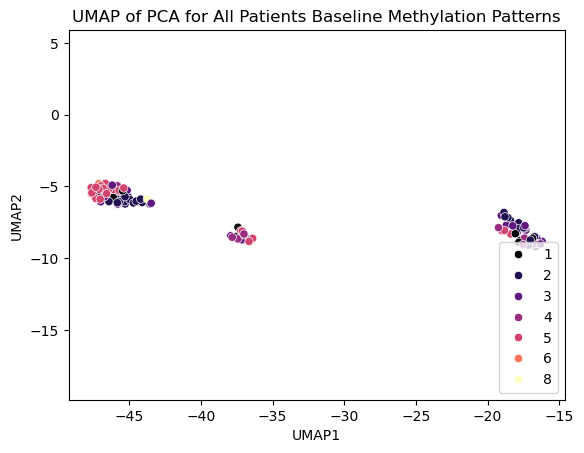

In [49]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'tumortype', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for All Patients Baseline Methylation Patterns")

## color is primary tumor presense

## color is mets present

In [50]:
metEnrollmentPresenceDF = pd.DataFrame.from_dict(metEnrollmentPresence, orient= 'index')
metEnrollmentPresenceDF

,0
BTO-003,1
BTO-004,1
BTO-005,1
BTO-006,1
BTO-007,1
...,...
BTO-129,2
BTO-130,2
BTO-131,4
BTO-132,4


In [51]:
embedding_df = pd.DataFrame(embedding)
embedding_df.index = y_train.index
embedding_wLabels = pd.concat([embedding_df,y_train,metEnrollmentPresenceDF], axis = 1)
embedding_wLabels.columns = ['UMAP1', 'UMAP2', 'tumortype',"numbmets"]
embedding_wLabels

,UMAP1,UMAP2,tumortype,numbmets
BTO-003,-37.412445,-7.850285,1,1
BTO-004,-46.038235,-5.577940,1,1
BTO-005,-45.285194,-6.223566,2,1
BTO-006,-45.807350,-5.575577,1,1
BTO-007,-45.052505,-5.728636,2,1
...,...,...,...,...
BTO-129,-45.379017,-5.114386,5,2
BTO-130,-47.598560,-5.449162,5,2
BTO-131,-19.245968,-7.874371,4,4
BTO-132,-47.318939,-5.057086,5,4


Text(0.5, 1.0, 'UMAP of PCA for All Patients Baseline Methylation Patterns')

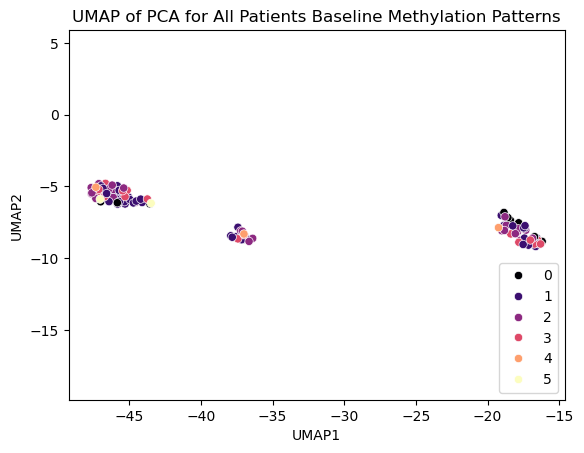

In [52]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'numbmets', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for All Patients Baseline Methylation Patterns")

## color is met sites

In [53]:
metEnrollmentLocDF = pd.DataFrame.from_dict(metEnrollmentDict, orient ='index')
metEnrollmentLocDF

,0,1,2,3,4
BTO-003,1.0,NaN,NaN,NaN,NaN
BTO-004,5.0,NaN,NaN,NaN,NaN
BTO-005,2.0,NaN,NaN,NaN,NaN
BTO-006,5.0,NaN,NaN,NaN,NaN
BTO-007,2.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...
BTO-129,1.0,5.0,NaN,NaN,NaN
BTO-130,1.0,2.0,NaN,NaN,NaN
BTO-131,1.0,2.0,4.0,5.0,NaN
BTO-132,1.0,2.0,5.0,6.0,NaN


In [54]:
metlocs = [1,2,3,4,5,6]
metLocsLong = {}
for ptID in metEnrollmentDict.keys():
    ptMetLocs = []
    for x in metlocs:
        if x in metEnrollmentDict[ptID]:
            ptMetLocs.append(x)
        else:
            ptMetLocs.append(0)
    metLocsLong[ptID] = ptMetLocs
metLocsLongDF = pd.DataFrame.from_dict(metLocsLong, orient ='index')
metLocsLongDF

,0,1,2,3,4,5
BTO-003,1,0,0,0,0,0
BTO-004,0,0,0,0,5,0
BTO-005,0,2,0,0,0,0
BTO-006,0,0,0,0,5,0
BTO-007,0,2,0,0,0,0
...,...,...,...,...,...,...
BTO-129,1,0,0,0,5,0
BTO-130,1,2,0,0,0,0
BTO-131,1,2,0,4,5,0
BTO-132,1,2,0,0,5,6


In [55]:
embedding_wLabels = pd.concat([embedding_wLabels, metLocsLongDF], axis =1)
embedding_wLabels

,UMAP1,UMAP2,tumortype,numbmets,0,1,2,3,4,5
BTO-003,-37.412445,-7.850285,1,1,1,0,0,0,0,0
BTO-004,-46.038235,-5.577940,1,1,0,0,0,0,5,0
BTO-005,-45.285194,-6.223566,2,1,0,2,0,0,0,0
BTO-006,-45.807350,-5.575577,1,1,0,0,0,0,5,0
BTO-007,-45.052505,-5.728636,2,1,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
BTO-129,-45.379017,-5.114386,5,2,1,0,0,0,5,0
BTO-130,-47.598560,-5.449162,5,2,1,2,0,0,0,0
BTO-131,-19.245968,-7.874371,4,4,1,2,0,4,5,0
BTO-132,-47.318939,-5.057086,5,4,1,2,0,0,5,6


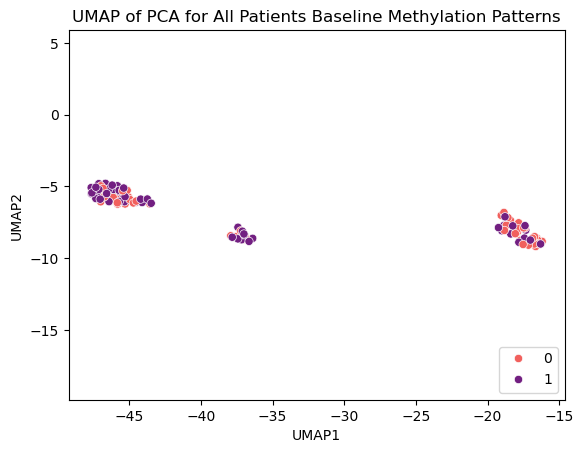

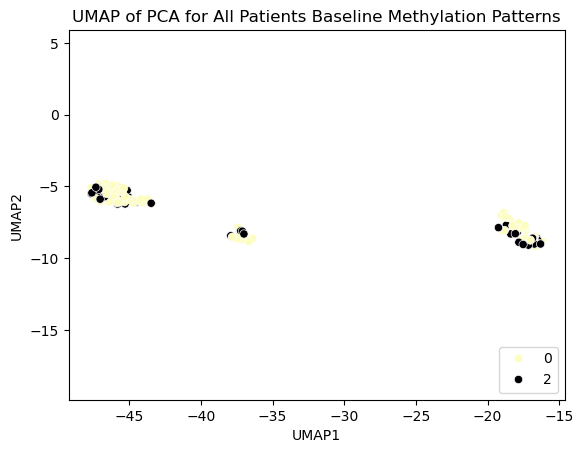

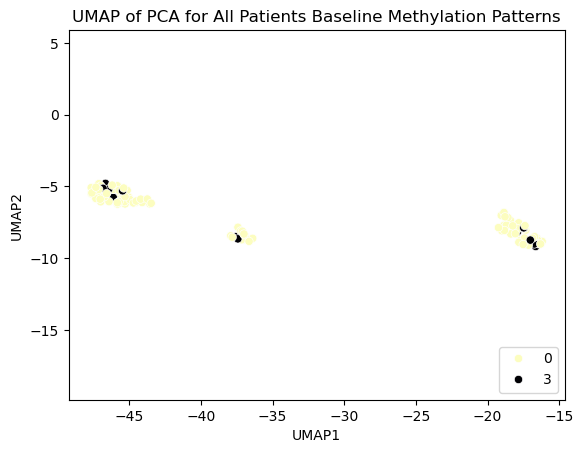

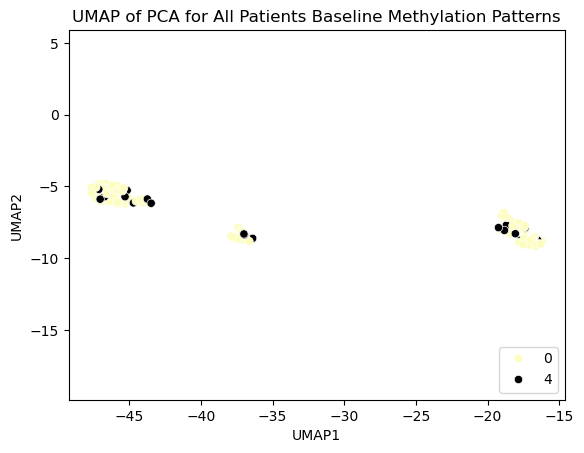

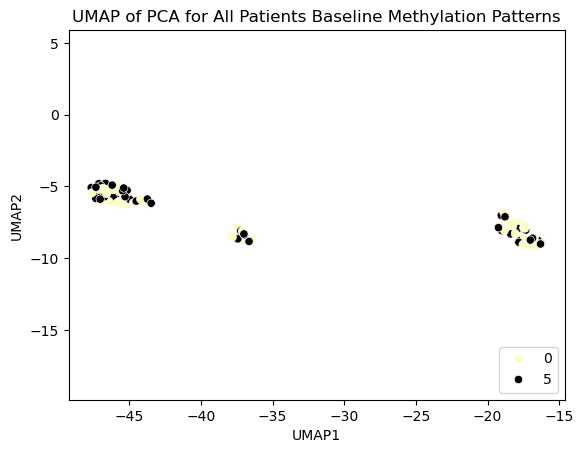

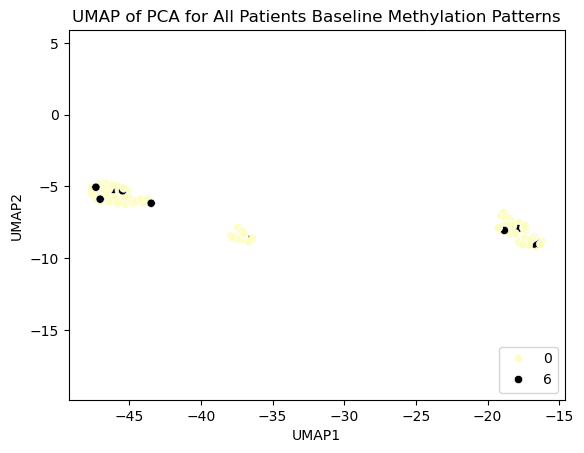

In [56]:
x = [0,1,2,3,4,5]
for met in x: 
    fig, ax = plt.subplots()
    ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = met, palette = 'magma_r', legend = 'full')
    #set plot dimensions equal on both axes
    plt.gca().set_aspect('equal', 'datalim')
    plt.legend(loc='lower right')
    plt.title("UMAP of PCA for All Patients Baseline Methylation Patterns")